# JOINT FITTING BETWEEN FERMI AND VERITAS (IN GAMMAPY) FOR A POINT SOURCE WITH POWER LAW SPECTRUM USING CRAB DATA

Anjana Kaushik Talluri

Note: The code below relies on J. Michael's model converter 

# Import packages

In [1]:
import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")



import matplotlib.pyplot as plt

import astropy.units as u
from threeML import *
from threeML.io.package_data import get_path_of_data_file



import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")
import shutil
from IPython.display import Image, display
import glob
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt
from astropy.io import fits as pyfits
import scipy as sp


from threeML import *



10:25:25 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=791522;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=258469;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#50\50]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=341111;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=24384;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#71\71]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=769282;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=325660;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py#36\36]8;;\
                  available                                                                                        

10:25:25 INFO      Starting 3ML!                                                                     ]8;id=25548;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=765124;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#31\31]8;;\

         WARNING   ROOT minimizer not available                                                ]8;id=53994;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=483072;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/minimizer/minimization.py#1345\1345]8;;\

...

10:25:26 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=81206;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=189343;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#79\79]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=590298;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=291675;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#129\129]8;;\
                  software installed and configured?                                                               

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=574966;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=588969;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=327703;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=639494;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=780783;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=368392;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/__init__.py#341\341]8;;\
                  performances in 3ML                                                                              

In [2]:
from astromodels import Powerlaw
from model_converter import SpectralModelGenerator
import astropy.units as u
import numpy as np

# Define a point source model with power law spectrum

In [3]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [4]:

f_model = Model(source)
f_model.display()
#ene = np.array([1,10,100])


Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [5]:
#gpy_p(ene)

In [6]:
#gpy_p


# VERITAS

In [7]:
import model_converter

from GammapyLike import GammapyLike

In [8]:
VERITAS = GammapyLike("VERITAS", config_file="config.yaml")

In [9]:
veritas_data = DataList(VERITAS)

In [1]:
# If checking just the veritas fit, use this
# jl = JointLikelihood(f_model, veritas_data, verbose=True)

# FERMI

In [11]:
lat_catalog = FermiLATSourceCatalog()

ra, dec, table = lat_catalog.search_around_source("Crab", radius=0.004)

table

Trying https://heasarc.gsfc.nasa.gov/cgi-bin/vo/cone/coneGet.pl?table=fermilpsc&


name,source_type,short_source_type,ra,dec,assoc_name,tevcat_assoc,Search_Offset
,,,deg,deg,,,
object,str32,object,float64,float64,object,object,float64
4FGL J0534.5+2200,"pulsar, identified by pulsations",PSR,83.6367,22.0149,PSR J0534+2200,Crab pulsar,0.2119


In [12]:
model = lat_catalog.get_model()

In [13]:
model.free_point_sources_within_radius(3.0, normalization_only=True)

model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (1):
--------------------

                   value min_value max_value            unit
PSR_J0534p2200...K   0.0       0.0       0.0  keV-1 s-1 cm-2

Fixed parameters (6):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [14]:
ra = 83.63
dec = 22.01

In [15]:
# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

10:26:09 INFO      Query parameters:                                                       ]8;id=699969;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=706515;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#262\262]8;;\

         INFO                          coordfield = 83.6300,22.0100                        ]8;id=760545;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=318594;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         coordsystem = J2000                                  ]8;id=439226;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=824455;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          shapefield = 20.0                                   ]8;id=822297;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=771329;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                           timefield = 2010-01-01 00:00:00,2010-02-01         ]8;id=448094;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=354473;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\
                  00:00:00                                                                                         

...

         INFO                         destination = query                                  ]8;id=210375;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=592932;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          spacecraft = checked                                ]8;id=639230;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=287071;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO      Query ID: e94fe495b65679baa926097eebf7f7fd                              ]8;id=636532;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=80341;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#271\271]8;;\

10:26:10 WARNING   Existing event file                                                     ]8;id=125802;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=855401;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#315\315]8;;\
                  [PosixPath('/Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-                         
                  plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_PH00.fits')] and                         
                  Spacecraft file                                                                                  
                  /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gamma                         
                  py_plugin/Crab_data/L220812144453F357373F65_SC00.fits correspond to the                          
                  same selection. We assume you did not tamper with them, so we will                               
                  return those instead of downloading them again. If you want to download                          
                  them again, remove them from the outdir                                                          

         WARNING   Existing merged event file                                               ]8;id=628989;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=772010;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#88\88]8;;\
                  /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammap                        
                  y_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits correspond                         
                  to the same selection. We assume you did not tamper with it, so we will                          
                  return it instead of merging it again. If you want to redo the FT1 file                          
                  again, remove it from the outdir                                                                 

In [16]:
import fermipy

In [17]:
config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [18]:
LAT = FermipyLike("LAT", config)
config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
fileio:
  outdir: __001f42fcf467f6472a624190907310b5
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /Users/anjanaktelidevara/Desktop/VERITAS/Internship/gammapy-plugin/gammapy_plugin/Crab_data/L220812144453F357373F65_SC00.fits
fileio:
 outdir: __001f42fcf467f6472a624190907310b5
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

# Joint fit 

In [19]:
data = DataList(VERITAS, LAT)

jl = JointLikelihood(f_model, data)
f_model.display()

10:26:18 INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=988809;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=87644;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/plugins/FermipyLike.py#105\105]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /opt/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


10:29:19 INFO      set the minimizer to minuit                                             ]8;id=329294;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=413501;file:///opt/anaconda3/envs/fermipy/lib/python3.9/site-packages/threeML/classicMLE/joint_likelihood.py#1042\1042]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [20]:
res = jl.fit()



Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(4.79 -0.32 +0.34) x 10^-9,1 / (cm2 keV s)
crab.spectrum.main.Powerlaw.index,-2.231 +/- 0.005,



Correlation matrix:



1.00,-0.97
-0.97,1.00



Values of -log(likelihood) at the minimum:



,-log(likelihood)
LAT,118046.031688
VERITAS,72.512478
total,118118.544166



Values of statistical measures:



,statistical measures
AIC,236241.088383
BIC,236261.865421


In [21]:
JF_result = jl.results

In [22]:
JF_result.display()

Best fit values:



,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(4.79 -0.32 +0.34) x 10^-9,1 / (cm2 keV s)
crab.spectrum.main.Powerlaw.index,-2.231 +/- 0.005,



Correlation matrix:



1.00,-0.97
-0.97,1.00



Values of -log(likelihood) at the minimum:



,-log(likelihood)
LAT,118046.031688
VERITAS,72.512478
total,118118.544166



Values of statistical measures:



,statistical measures
AIC,236241.088383
BIC,236261.865421


In [23]:
res = jl.get_errors()

,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,4.79 -0.32 +0.34,1 / (cm2 s TeV)
crab.spectrum.main.Powerlaw.index,-2.231 -0.005 +0.004,


# Some plots

Profiling likelihood:   0%|                              | 0/30 [00:00<?, ?it/s]

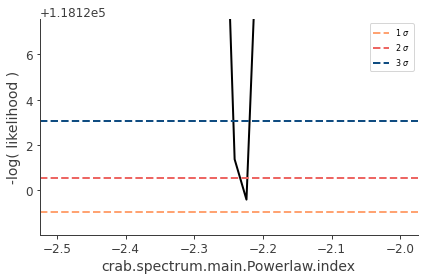

In [25]:
res = jl.get_contours(
    f_model.crab.spectrum.main.Powerlaw.index, -2.5, -2, 30
)

Profiling likelihood:   0%|                              | 0/30 [00:00<?, ?it/s]

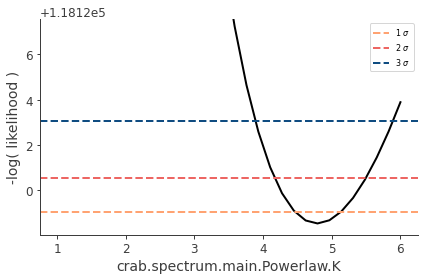

In [28]:
res = jl.get_contours(
    f_model.crab.spectrum.main.Powerlaw.K, 1,6, 30
)

Profiling likelihood:   0%|                             | 0/900 [00:00<?, ?it/s]

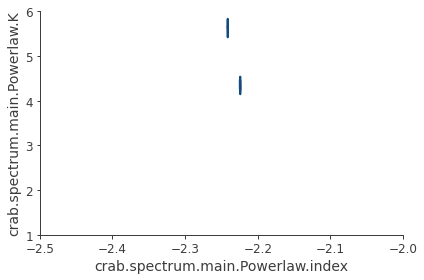

In [29]:
res = jl.get_contours(
    "crab.spectrum.main.Powerlaw.K", 1, 6, 30,
    "crab.spectrum.main.Powerlaw.index",
    -2.5, -2, 30)

In [30]:
fluxes = jl.results.get_flux(100 * u.keV, 1 * u.MeV)

# Same results would be obtained with
# fluxes = results_reloaded.get_point_source_flux(100 * u.keV, 1 * u.MeV)

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

processing MLE analyses:   0%|                            | 0/1 [00:00<?, ?it/s]

Propagating errors:   0%|                               | 0/500 [00:00<?, ?it/s]

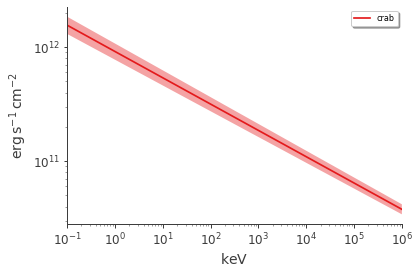

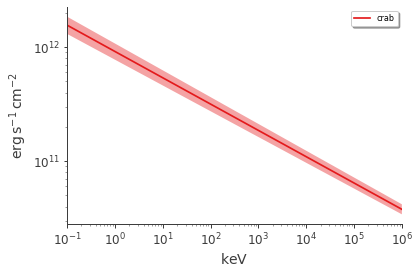

In [31]:
plot_spectra(jl.results, ene_min=0.1, ene_max=1e6, num_ene=500, 
                          flux_unit='erg / (cm2 s)')